# 🌲 ElectioAnalytics — Modèle Multiclasse
**Algorithme :** Random Forest  
**Cible :** `bloc_vainqueur` — DROITE (0) / CENTRE (1) / GAUCHE (2)  
**Comparaison :** Version A (avec historique électoral) vs Version B (socio-éco pur)  

---

## ⚙️ 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

FINAL_PATH  = 'data/final'
MODELS_PATH = 'data/models'
os.makedirs(MODELS_PATH, exist_ok=True)

COLS_CIBLES = ['cible_binaire', 'cible_multiclasse', 'cible_transition_enc']
CLASSES     = ['DROITE', 'CENTRE', 'GAUCHE']
COULEURS    = {'DROITE': '#c0392b', 'CENTRE': '#f39c12', 'GAUCHE': '#2980b9'}

print('✅ Imports OK')

✅ Imports OK


---
## 📂 1 — Chargement des datasets

In [2]:
datasets = {}
for version in ['A', 'B']:
    train = pd.read_csv(f'{FINAL_PATH}/ml_train_2017_v{version}.csv', dtype={'code_geo': str})
    test  = pd.read_csv(f'{FINAL_PATH}/ml_test_2022_v{version}.csv',  dtype={'code_geo': str})
    features = [c for c in train.columns
                if (c.endswith('_scaled') or c.endswith('_enc'))
                and c not in COLS_CIBLES]
    datasets[version] = {'train': train, 'test': test, 'features': features}
    print(f'Version {version} — {len(features)} features : {features}')

print(f'\nTrain : {len(datasets["A"]["train"])} communes (2017)')
print(f'Test  : {len(datasets["A"]["test"])} communes (2022)')

Version A — 7 features : ['bloc_cand1_enc', 'bloc_cand2_enc', 'bloc_cand3_enc', 'bloc_cand5_enc', 'taux_faible_diplome_scaled', 'revenu_median_scaled', 'log_delinquance_scaled']
Version B — 5 features : ['taux_faible_diplome_scaled', 'revenu_median_scaled', 'log_delinquance_scaled', 'log_population_scaled', 'pct_abstention_scaled']

Train : 648 communes (2017)
Test  : 648 communes (2022)


In [3]:
# Distribution de la cible multiclasse
# ⚠️  GAUCHE trop rare (13-14 communes) → fusionner avec DIVERS en NON-DROITE-NON-CENTRE
# On travaille sur 3 classes : DROITE / CENTRE / GAUCHE
# GAUCHE sera gardé mais traité avec class_weight

mapping_inv = {0: 'DROITE', 1: 'CENTRE', 2: 'GAUCHE'}

for version in ['A', 'B']:
    y_train = datasets[version]['train']['cible_multiclasse'].values
    y_test  = datasets[version]['test']['cible_multiclasse'].values
    print(f'\nVersion {version} :')
    print(f'   Train : ', {mapping_inv[k]: int((y_train==k).sum()) for k in [0,1,2]})
    print(f'   Test  : ', {mapping_inv[k]: int((y_test==k).sum())  for k in [0,1,2]})


Version A :
   Train :  {'DROITE': 598, 'CENTRE': 36, 'GAUCHE': 14}
   Test  :  {'DROITE': 470, 'CENTRE': 165, 'GAUCHE': 13}

Version B :
   Train :  {'DROITE': 598, 'CENTRE': 36, 'GAUCHE': 14}
   Test  :  {'DROITE': 470, 'CENTRE': 165, 'GAUCHE': 13}


---
## 🔧 2 — Optimisation des hyperparamètres (GridSearch)

In [4]:
# GridSearch uniquement sur Version B (la plus utile pour 2027)
# On cherche les meilleurs hyperparamètres avant l'entraînement final

train_b    = datasets['B']['train']
features_b = datasets['B']['features']
X_gs       = train_b[features_b].values
y_gs       = train_b['cible_multiclasse'].values

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'class_weight':      ['balanced']
}

cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv_gs,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_gs, y_gs)

print(f'\n✅ Meilleurs hyperparamètres (Version B) :')
for k, v in grid_search.best_params_.items():
    print(f'   {k:<25} : {v}')
print(f'\n   F1 macro CV (best) : {grid_search.best_score_:.3f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Meilleurs hyperparamètres (Version B) :
   class_weight              : balanced
   max_depth                 : 5
   min_samples_split         : 5
   n_estimators              : 200

   F1 macro CV (best) : 0.630


---
## 🤖 3 — Entraînement et Cross-Validation (k=5)

In [5]:
best_params = grid_search.best_params_
resultats   = {}
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for version in ['A', 'B']:
    train    = datasets[version]['train']
    features = datasets[version]['features']
    X_train  = train[features].values
    y_train  = train['cible_multiclasse'].values

    # Version A : hyperparamètres par défaut optimisés
    # Version B : hyperparamètres du GridSearch
    params = best_params if version == 'B' else {
        'n_estimators': 200, 'max_depth': None,
        'min_samples_split': 2, 'class_weight': 'balanced'
    }

    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)

    cv_results = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        return_train_score=True
    )

    resultats[version] = {
        'model': model, 'features': features,
        'cv': cv_results,
        'X_train': X_train, 'y_train': y_train,
        'params': params
    }

    print(f'\n── Version {version} ──')
    df_cv = pd.DataFrame({
        'Métrique':   ['Accuracy', 'F1 Macro', 'F1 Weighted'],
        'Train moy':  [cv_results['train_accuracy'].mean(),
                       cv_results['train_f1_macro'].mean(),
                       cv_results['train_f1_weighted'].mean()],
        'Val moy':    [cv_results['test_accuracy'].mean(),
                       cv_results['test_f1_macro'].mean(),
                       cv_results['test_f1_weighted'].mean()],
        'Val std':    [cv_results['test_accuracy'].std(),
                       cv_results['test_f1_macro'].std(),
                       cv_results['test_f1_weighted'].std()],
    }).set_index('Métrique').round(3)
    df_cv['Overfit?'] = (df_cv['Train moy'] - df_cv['Val moy']).apply(
        lambda x: '⚠️ Oui' if x > 0.1 else '✅ Non'
    )
    display(df_cv)


── Version A ──


,Train moy,Val moy,Val std,Overfit?
Métrique,,,,
Accuracy,1.0,0.998,0.003,✅ Non
F1 Macro,1.0,0.995,0.011,✅ Non
F1 Weighted,1.0,0.998,0.003,✅ Non



── Version B ──


,Train moy,Val moy,Val std,Overfit?
Métrique,,,,
Accuracy,0.937,0.883,0.031,✅ Non
F1 Macro,0.835,0.630,0.102,⚠️ Oui
F1 Weighted,0.946,0.897,0.021,✅ Non


---
## 🧪 4 — Évaluation sur le test 2022

In [6]:
for version in ['A', 'B']:
    train    = datasets[version]['train']
    test     = datasets[version]['test']
    features = datasets[version]['features']

    X_train  = train[features].values
    y_train  = train['cible_multiclasse'].values
    X_test   = test[features].values
    y_test   = test['cible_multiclasse'].values

    model = resultats[version]['model']
    model.fit(X_train, y_train)

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    resultats[version].update({
        'y_test':       y_test,
        'y_pred':       y_pred,
        'y_pred_proba': y_pred_proba,
        'acc':          accuracy_score(y_test, y_pred),
        'f1_macro':     f1_score(y_test, y_pred, average='macro'),
        'f1_weighted':  f1_score(y_test, y_pred, average='weighted'),
        'cm':           confusion_matrix(y_test, y_pred, labels=[0,1,2]),
        'test_df':      test.copy(),
        'X_test':       X_test
    })

    joblib.dump(model, f'{MODELS_PATH}/model_multiclasse_v{version}.pkl')

    print(f'\n── Version {version} ──')
    print(classification_report(
        y_test, y_pred,
        target_names=CLASSES,
        digits=3,
        labels=[0, 1, 2]
    ))


── Version A ──
              precision    recall  f1-score   support

      DROITE      0.994     1.000     0.997       470
      CENTRE      1.000     0.982     0.991       165
      GAUCHE      1.000     1.000     1.000        13

    accuracy                          0.995       648
   macro avg      0.998     0.994     0.996       648
weighted avg      0.995     0.995     0.995       648


── Version B ──
              precision    recall  f1-score   support

      DROITE      0.769     0.983     0.863       470
      CENTRE      0.732     0.182     0.291       165
      GAUCHE      0.667     0.308     0.421        13

    accuracy                          0.765       648
   macro avg      0.722     0.491     0.525       648
weighted avg      0.757     0.765     0.708       648



---
## 📊 5 — Comparaison Version A vs Version B

In [7]:
df_comp = pd.DataFrame({
    'Version A': [
        f"{resultats['A']['acc']:.3f}",
        f"{resultats['A']['f1_macro']:.3f}",
        f"{resultats['A']['f1_weighted']:.3f}",
        f"{resultats['A']['cv']['test_accuracy'].mean():.3f} "
        f"± {resultats['A']['cv']['test_accuracy'].std():.3f}"
    ],
    'Version B': [
        f"{resultats['B']['acc']:.3f}",
        f"{resultats['B']['f1_macro']:.3f}",
        f"{resultats['B']['f1_weighted']:.3f}",
        f"{resultats['B']['cv']['test_accuracy'].mean():.3f} "
        f"± {resultats['B']['cv']['test_accuracy'].std():.3f}"
    ],
    'Écart A-B': [
        f"{resultats['A']['acc']       - resultats['B']['acc']:+.3f}",
        f"{resultats['A']['f1_macro']  - resultats['B']['f1_macro']:+.3f}",
        f"{resultats['A']['f1_weighted'] - resultats['B']['f1_weighted']:+.3f}",
        '—'
    ]
}, index=['Accuracy (test)', 'F1 Macro (test)',
          'F1 Weighted (test)', 'CV Accuracy (train)'])

print('📊 Tableau comparatif Random Forest A vs B :')
display(df_comp)

# Comparaison avec le modèle binaire
print('\n📊 Comparaison Régression Logistique vs Random Forest (Version B) :')
df_algo = pd.DataFrame({
    'Reg. Logistique (B)': ['88.7%', '0.787 (F1 bin.)', '—'],
    'Random Forest (B)':   [
        f"{resultats['B']['acc']*100:.1f}%",
        f"{resultats['B']['f1_macro']:.3f} (F1 macro)",
        f"{resultats['B']['f1_weighted']:.3f} (F1 weighted)"
    ]
}, index=['Accuracy', 'F1', 'F1 weighted'])
display(df_algo)

📊 Tableau comparatif Random Forest A vs B :


,Version A,Version B,Écart A-B
Accuracy (test),0.995,0.765,+0.230
F1 Macro (test),0.996,0.525,+0.471
F1 Weighted (test),0.995,0.708,+0.287
CV Accuracy (train),0.998 ± 0.003,0.883 ± 0.031,—



📊 Comparaison Régression Logistique vs Random Forest (Version B) :


,Reg. Logistique (B),Random Forest (B)
Accuracy,88.7%,76.5%
F1,0.787 (F1 bin.),0.525 (F1 macro)
F1 weighted,—,0.708 (F1 weighted)


---
## 🟦 6 — Matrices de Confusion

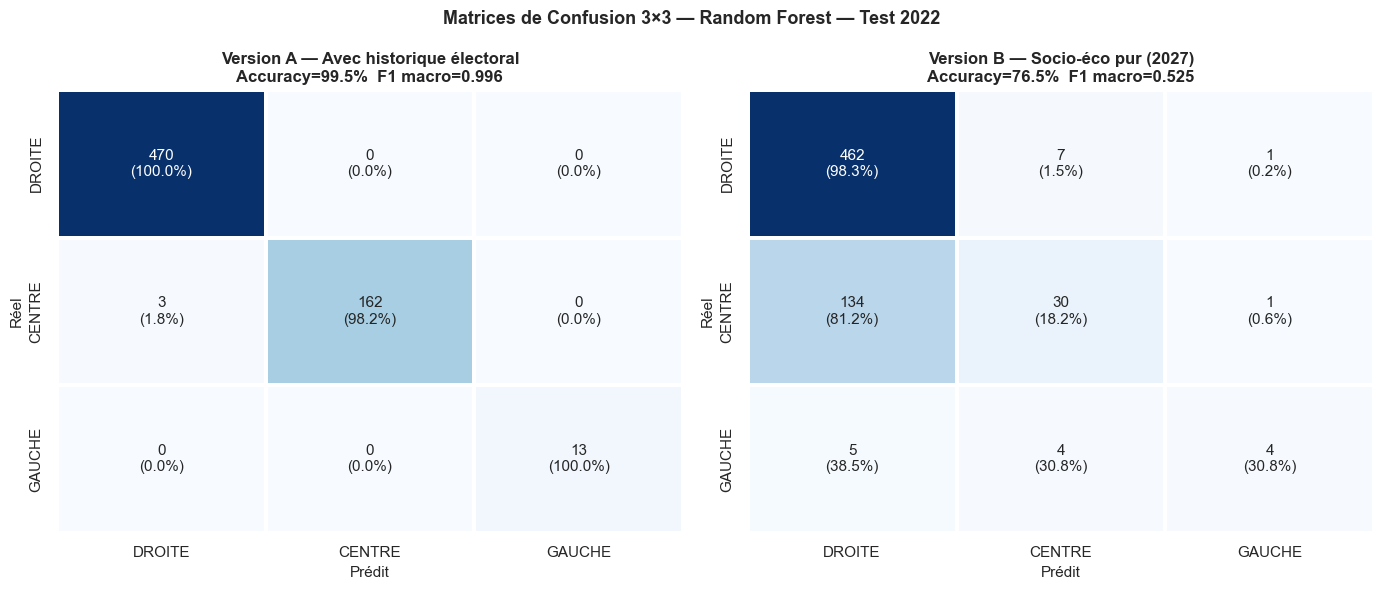

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, version in zip(axes, ['A', 'B']):
    cm     = resultats[version]['cm']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = np.array([
        [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(3)]
        for i in range(3)
    ])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=1.5, cbar=False,
                annot_kws={'size': 11})

    acc      = resultats[version]['acc']
    f1_macro = resultats[version]['f1_macro']
    desc     = 'Avec historique électoral' if version == 'A' else 'Socio-éco pur (2027)'
    ax.set_title(
        f'Version {version} — {desc}\n'
        f'Accuracy={acc:.1%}  F1 macro={f1_macro:.3f}',
        fontweight='bold'
    )
    ax.set_xlabel('Prédit', fontsize=11)
    ax.set_ylabel('Réel',   fontsize=11)

plt.suptitle('Matrices de Confusion 3×3 — Random Forest — Test 2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/confusion_multiclasse.png', dpi=120)
plt.show()

---
## 🌲 7 — Feature Importance

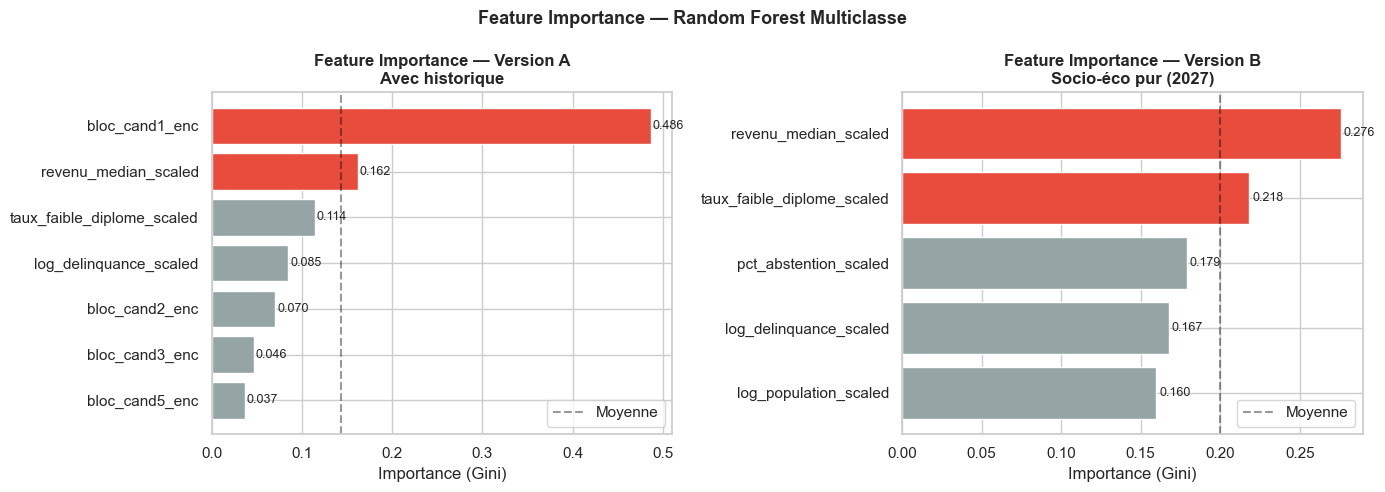


📋 Feature Importance Version B (prédiction 2027) :
   revenu_median_scaled                : 0.2758  █████████████
   taux_faible_diplome_scaled          : 0.2180  ██████████
   pct_abstention_scaled               : 0.1789  ████████
   log_delinquance_scaled              : 0.1675  ████████
   log_population_scaled               : 0.1599  ███████


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, version in zip(axes, ['A', 'B']):
    model    = resultats[version]['model']
    features = resultats[version]['features']

    importance_df = pd.DataFrame({
        'feature':    features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=True)

    colors = ['#e74c3c' if imp > importance_df['importance'].mean()
              else '#95a5a6' for imp in importance_df['importance']]

    ax.barh(importance_df['feature'], importance_df['importance'],
            color=colors, edgecolor='white')
    ax.axvline(x=importance_df['importance'].mean(),
               color='black', linestyle='--', alpha=0.4, label='Moyenne')
    desc = 'Avec historique' if version == 'A' else 'Socio-éco pur (2027)'
    ax.set_title(f'Feature Importance — Version {version}\n{desc}',
                 fontweight='bold')
    ax.set_xlabel('Importance (Gini)')
    ax.legend()

    # Afficher les valeurs
    for i, (_, row) in enumerate(importance_df.iterrows()):
        ax.text(row['importance'] + 0.002, i,
                f"{row['importance']:.3f}", va='center', fontsize=9)

plt.suptitle('Feature Importance — Random Forest Multiclasse',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/feature_importance_rf.png', dpi=120)
plt.show()

print('\n📋 Feature Importance Version B (prédiction 2027) :')
for _, row in importance_df.sort_values('importance', ascending=False).iterrows():
    barre = '█' * int(row['importance'] * 50)
    print(f"   {row['feature']:<35} : {row['importance']:.4f}  {barre}")

---
## 🏙️ 8 — Probabilités par classe par commune (Version B)

/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_49866/709361732.py:45: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pg/5td0t39x2sv6xzk1jx5p5c0c0000gp/T/ipykernel_49866/709361732.py:46: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(f'{MODELS_PATH}/probas_bascule_multiclasse.png', dpi=120)
/Users/Princia/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


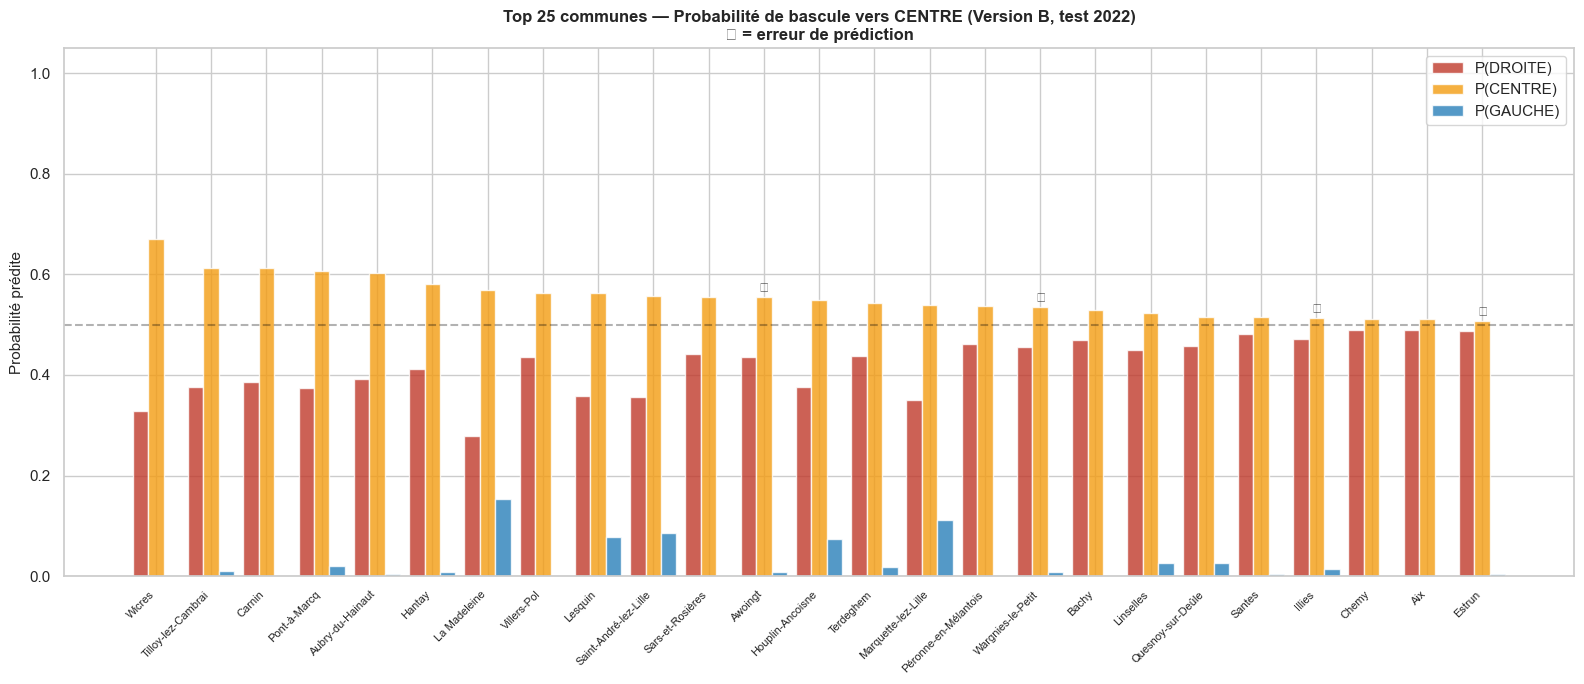

In [10]:
# Communes avec la plus forte probabilité de basculer vers CENTRE
test_b = resultats['B']['test_df'].copy()
proba  = resultats['B']['y_pred_proba']

test_b['proba_DROITE'] = proba[:, 0]
test_b['proba_CENTRE'] = proba[:, 1]
test_b['proba_GAUCHE'] = proba[:, 2]
test_b['pred_classe']  = resultats['B']['y_pred']
test_b['reel_classe']  = resultats['B']['y_test']
test_b['correct']      = (test_b['pred_classe'] == test_b['reel_classe'])

# Top 25 communes les plus susceptibles de basculer vers CENTRE
top_bascule = test_b.sort_values('proba_CENTRE', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(16, 7))
x       = np.arange(len(top_bascule))
w       = 0.28

ax.bar(x - w, top_bascule['proba_DROITE'], w,
       label='P(DROITE)',  color='#c0392b', alpha=0.8)
ax.bar(x,     top_bascule['proba_CENTRE'], w,
       label='P(CENTRE)',  color='#f39c12', alpha=0.8)
ax.bar(x + w, top_bascule['proba_GAUCHE'], w,
       label='P(GAUCHE)',  color='#2980b9', alpha=0.8)

# Marquer les erreurs
for i, (_, row) in enumerate(top_bascule.iterrows()):
    if not row['correct']:
        ax.text(i, max(row['proba_DROITE'], row['proba_CENTRE'],
                       row['proba_GAUCHE']) + 0.01,
                '✗', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(top_bascule['libelle_commune'],
                    rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Probabilité prédite', fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.3)
ax.set_title(
    'Top 25 communes — Probabilité de bascule vers CENTRE (Version B, test 2022)\n'
    '✗ = erreur de prédiction',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/probas_bascule_multiclasse.png', dpi=120)
plt.show()

---
## 🔍 9 — Analyse des erreurs (Version B)

In [11]:
mapping_inv = {0: 'DROITE', 1: 'CENTRE', 2: 'GAUCHE'}
test_b['bloc_predit'] = test_b['pred_classe'].map(mapping_inv)
test_b['bloc_reel']   = test_b['reel_classe'].map(mapping_inv)

erreurs = test_b[~test_b['correct']].copy()
print(f'❌ Erreurs totales : {len(erreurs)}/{len(test_b)} '
      f'({len(erreurs)/len(test_b)*100:.1f}%)')

print('\n📊 Matrice des erreurs (réel → prédit) :')
display(pd.crosstab(
    erreurs['bloc_reel'],
    erreurs['bloc_predit'],
    rownames=['Réel →'],
    colnames=['→ Prédit']
))

# Erreurs les plus critiques : CENTRE prédit comme DROITE
centre_rate = test_b[
    (test_b['bloc_reel'] == 'CENTRE') &
    (test_b['bloc_predit'] == 'DROITE')
].copy()

print(f'\n⚠️  CENTRE réel prédit comme DROITE : {len(centre_rate)} communes')
if len(centre_rate) > 0:
    display(centre_rate[[
        'libelle_commune', 'bloc_reel', 'bloc_predit',
        'proba_CENTRE', 'proba_DROITE'
    ]].sort_values('proba_CENTRE', ascending=False).head(10).reset_index(drop=True))

❌ Erreurs totales : 152/648 (23.5%)

📊 Matrice des erreurs (réel → prédit) :


→ Prédit,CENTRE,DROITE,GAUCHE
Réel →,,,
CENTRE,0,134,1
DROITE,7,0,1
GAUCHE,4,5,0



⚠️  CENTRE réel prédit comme DROITE : 134 communes


,libelle_commune,bloc_reel,bloc_predit,proba_CENTRE,proba_DROITE
0,Tilloy-lez-Marchiennes,CENTRE,DROITE,0.498100,0.501900
1,Camphin-en-Carembault,CENTRE,DROITE,0.489994,0.496754
2,Erquinghem-le-Sec,CENTRE,DROITE,0.489719,0.509108
3,Wannehain,CENTRE,DROITE,0.487111,0.503837
4,Bouvignies,CENTRE,DROITE,0.483135,0.507814
5,Saint-Jans-Cappel,CENTRE,DROITE,0.480613,0.511134
6,Herlies,CENTRE,DROITE,0.478176,0.507772
7,Auchy-lez-Orchies,CENTRE,DROITE,0.475666,0.504109
8,Jolimetz,CENTRE,DROITE,0.475215,0.520584
9,Estreux,CENTRE,DROITE,0.471854,0.528146


---
## 🔮 10 — Simulation 2027 (Version B)

In [12]:
# Simulation : que se passe-t-il si les conditions socio-éco 2022
# évoluent de ±10% sur les features clés ?
# C'est notre projection conditionnelle à 2027

model_b   = resultats['B']['model']
features_b = resultats['B']['features']
test_b_data = resultats['B']['test_df'].copy()
X_base    = resultats['B']['X_test'].copy()

scenarios = {
    'Baseline 2022': X_base.copy(),
    'Diplômes +10%':  X_base.copy(),
    'Revenu +10%':    X_base.copy(),
    'Diplômes -10%':  X_base.copy(),
}

# Trouver les indices des features
idx_diplome = features_b.index('taux_faible_diplome_scaled') if 'taux_faible_diplome_scaled' in features_b else None
idx_revenu  = features_b.index('revenu_median_scaled') if 'revenu_median_scaled' in features_b else None

if idx_diplome is not None:
    scenarios['Diplômes +10%'][:, idx_diplome] *= 1.1   # plus de faible diplôme
    scenarios['Diplômes -10%'][:, idx_diplome] *= 0.9   # moins de faible diplôme
if idx_revenu is not None:
    scenarios['Revenu +10%'][:, idx_revenu]    *= 1.1   # revenus augmentent

print('📊 Simulation de scénarios 2027 — Distribution des blocs prédits :')
print(f'   {"Scénario":<25} {"DROITE":>10} {"CENTRE":>10} {"GAUCHE":>10}')
print('-' * 60)

resultats_scenarios = {}
for nom, X_sc in scenarios.items():
    y_sc = model_b.predict(X_sc)
    n_d  = (y_sc == 0).sum()
    n_c  = (y_sc == 1).sum()
    n_g  = (y_sc == 2).sum()
    resultats_scenarios[nom] = {'DROITE': n_d, 'CENTRE': n_c, 'GAUCHE': n_g}
    print(f'   {nom:<25} {n_d:>7} ({n_d/648*100:.1f}%) {n_c:>7} ({n_c/648*100:.1f}%) {n_g:>7} ({n_g/648*100:.1f}%)')

📊 Simulation de scénarios 2027 — Distribution des blocs prédits :
   Scénario                      DROITE     CENTRE     GAUCHE
------------------------------------------------------------
   Baseline 2022                 601 (92.7%)      41 (6.3%)       6 (0.9%)
   Diplômes +10%                 601 (92.7%)      41 (6.3%)       6 (0.9%)
   Revenu +10%                   609 (94.0%)      33 (5.1%)       6 (0.9%)
   Diplômes -10%                 611 (94.3%)      32 (4.9%)       5 (0.8%)


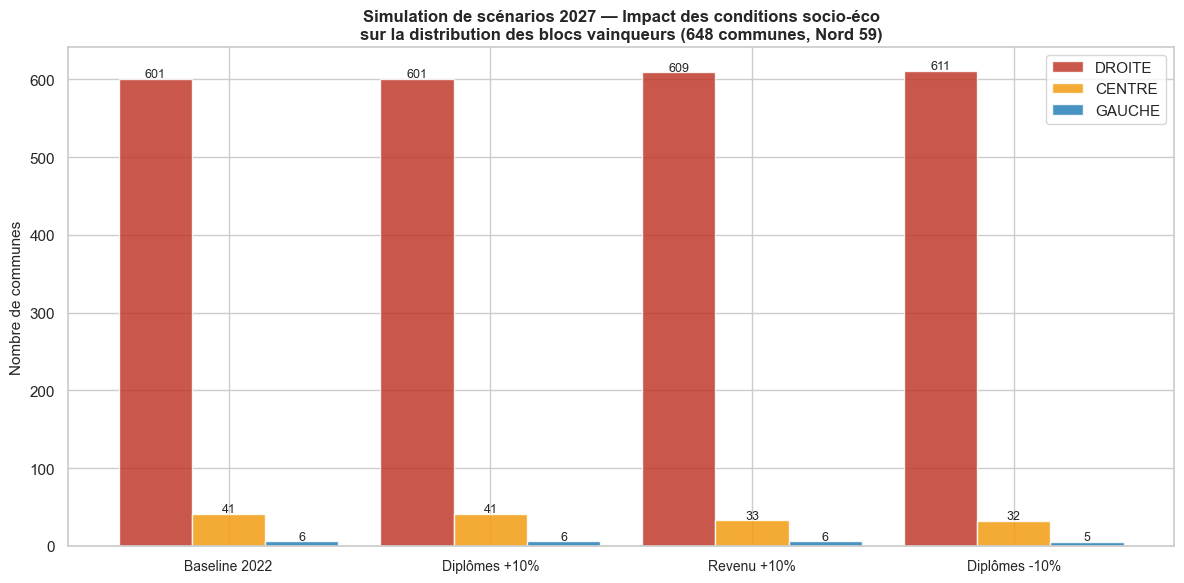

In [13]:
# Visualisation des scénarios
fig, ax = plt.subplots(figsize=(12, 6))

scenarios_noms = list(resultats_scenarios.keys())
x = np.arange(len(scenarios_noms))
w = 0.28

vals_d = [resultats_scenarios[s]['DROITE'] for s in scenarios_noms]
vals_c = [resultats_scenarios[s]['CENTRE'] for s in scenarios_noms]
vals_g = [resultats_scenarios[s]['GAUCHE'] for s in scenarios_noms]

ax.bar(x - w, vals_d, w, label='DROITE',  color='#c0392b', alpha=0.85)
ax.bar(x,     vals_c, w, label='CENTRE',  color='#f39c12', alpha=0.85)
ax.bar(x + w, vals_g, w, label='GAUCHE',  color='#2980b9', alpha=0.85)

for i, (vd, vc, vg) in enumerate(zip(vals_d, vals_c, vals_g)):
    ax.text(i - w, vd + 2, str(vd), ha='center', fontsize=9)
    ax.text(i,     vc + 2, str(vc), ha='center', fontsize=9)
    ax.text(i + w, vg + 2, str(vg), ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(scenarios_noms, fontsize=10)
ax.set_ylabel('Nombre de communes', fontsize=11)
ax.set_title(
    'Simulation de scénarios 2027 — Impact des conditions socio-éco\n'
    'sur la distribution des blocs vainqueurs (648 communes, Nord 59)',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/scenarios_2027.png', dpi=120)
plt.show()

---
## 📋 11 — Bilan Final

In [14]:
print('=' * 65)
print('📋 BILAN MODÈLE MULTICLASSE — Random Forest')
print('=' * 65)

for version in ['A', 'B']:
    r      = resultats[version]
    cv_acc = r['cv']['test_accuracy'].mean()
    cv_std = r['cv']['test_accuracy'].std()
    desc   = 'Avec historique électoral' if version == 'A' else 'Socio-éco pur (2027)'
    print(f"""
Version {version} — {desc}
   CV Accuracy (k=5)  : {cv_acc:.3f} ± {cv_std:.3f}
   Test Accuracy 2022 : {r['acc']:.3f}  ({r['acc']*100:.1f}%)
   F1 Macro           : {r['f1_macro']:.3f}
   F1 Weighted        : {r['f1_weighted']:.3f}""")

print(f"""
Comparaison des deux modèles sur Version B
   Régression Logistique (binaire)  : Accuracy=88.7%  F1=0.787
   Random Forest (multiclasse)      : Accuracy={resultats['B']['acc']*100:.1f}%  F1 macro={resultats['B']['f1_macro']:.3f}

Fichiers sauvegardés
   data/models/model_multiclasse_vA.pkl
   data/models/model_multiclasse_vB.pkl
   data/models/confusion_multiclasse.png
   data/models/feature_importance_rf.png
   data/models/probas_bascule_multiclasse.png
   data/models/scenarios_2027.png

🚀 Prochaine étape : visualisations + dossier de synthèse""")

📋 BILAN MODÈLE MULTICLASSE — Random Forest

Version A — Avec historique électoral
   CV Accuracy (k=5)  : 0.998 ± 0.003
   Test Accuracy 2022 : 0.995  (99.5%)
   F1 Macro           : 0.996
   F1 Weighted        : 0.995

Version B — Socio-éco pur (2027)
   CV Accuracy (k=5)  : 0.883 ± 0.031
   Test Accuracy 2022 : 0.765  (76.5%)
   F1 Macro           : 0.525
   F1 Weighted        : 0.708

Comparaison des deux modèles sur Version B
   Régression Logistique (binaire)  : Accuracy=88.7%  F1=0.787
   Random Forest (multiclasse)      : Accuracy=76.5%  F1 macro=0.525

Fichiers sauvegardés
   data/models/model_multiclasse_vA.pkl
   data/models/model_multiclasse_vB.pkl
   data/models/confusion_multiclasse.png
   data/models/feature_importance_rf.png
   data/models/probas_bascule_multiclasse.png
   data/models/scenarios_2027.png

🚀 Prochaine étape : visualisations + dossier de synthèse


In [ ]:
# ================================================================
# TOUTES LES COURBES — model_multiclasse.ipynb
# Chaque graphique dans sa propre figure séparée
# À coller dans une nouvelle cellule à la fin du notebook
# ================================================================

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs(MODELS_PATH, exist_ok=True)

NAVY   = "#0D1B2A"
BLUE   = "#1565C0"
RED    = "#E53935"
GREEN  = "#2E7D32"
GOLD   = "#FFB300"
ORANGE = "#E65100"

CLASSES  = ['DROITE', 'CENTRE', 'GAUCHE']

# ================================================================
# PRÉPARATION DES DONNÉES MLP (Version B — socio-éco pur)
# ================================================================
version  = 'B'
train_b  = datasets[version]['train']
test_b   = datasets[version]['test']
features = datasets[version]['features']

X_train_b = train_b[features].values
y_train_b = train_b['cible_multiclasse'].values
X_test_b  = test_b[features].values
y_test_b  = test_b['cible_multiclasse'].values

# ── MLP entraîné epoch par epoch ──────────────────────────────
train_acc_h, val_acc_h, loss_h = [], [], []

mlp = MLPClassifier(
    hidden_layer_sizes = (128, 64, 32),  # 3 couches — multi-classe plus complexe
    activation         = 'relu',
    max_iter           = 1,
    warm_start         = True,
    random_state       = 42,
    learning_rate_init = 0.001,
    solver             = 'adam'
)

N_EPOCHS = 100
print("Entraînement MLP multi-classe...")
for _ in range(N_EPOCHS):
    mlp.fit(X_train_b, y_train_b)
    train_acc_h.append(mlp.score(X_train_b, y_train_b))
    val_acc_h.append(mlp.score(X_test_b,   y_test_b))
    loss_h.append(mlp.loss_)

print(f"✅ MLP — Accuracy test 2022 : {val_acc_h[-1]*100:.1f}%")

# ================================================================
# FIGURE 1 — Courbe de Précision MLP (Train vs Validation)
# ================================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F7FA')

ax.plot(train_acc_h, label='Train (2017)',      color=BLUE,  linewidth=2.5)
ax.plot(val_acc_h,   label='Validation (2022)', color=RED,   linewidth=2.5, linestyle='--')
ax.axhline(max(val_acc_h), color=GREEN, linestyle=':', linewidth=1.5,
           label=f'Max val = {max(val_acc_h)*100:.1f}%')
ax.axhline(1/3, color='gray', linestyle=':', linewidth=1, alpha=0.5,
           label='Baseline aléatoire (33%)')
ax.fill_between(range(N_EPOCHS), train_acc_h, val_acc_h, alpha=0.07, color=RED)

gap = train_acc_h[-1] - val_acc_h[-1]
ax.annotate(f'Écart final : {gap*100:.1f}%',
            xy=(N_EPOCHS-1, (train_acc_h[-1]+val_acc_h[-1])/2),
            xytext=(N_EPOCHS-32, (train_acc_h[-1]+val_acc_h[-1])/2 - 0.08),
            fontsize=10, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

ax.set_title('Courbe de Précision — MLP\nClassification Multi-Classe (DROITE / CENTRE / GAUCHE) | Nord (59)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Époque', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.2, 1.05)
ax.set_xlim(0, N_EPOCHS)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig1_courbe_precision.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 1 — Courbe de précision")

# ================================================================
# FIGURE 2 — Courbe de Perte MLP
# ================================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F7FA')

ax.plot(loss_h, color=ORANGE, linewidth=2.5, label='Train Loss')
ax.fill_between(range(N_EPOCHS), loss_h, alpha=0.15, color=ORANGE)
ax.annotate(f'Loss finale : {loss_h[-1]:.3f}',
            xy=(N_EPOCHS-1, loss_h[-1]),
            xytext=(N_EPOCHS-35, loss_h[-1] + (loss_h[0]-loss_h[-1])*0.15),
            fontsize=10, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))

ax.set_title('Courbe de Perte (Loss) — MLP\nClassification Multi-Classe (DROITE / CENTRE / GAUCHE) | Nord (59)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Époque', fontsize=12)
ax.set_ylabel('Loss (entropie croisée)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, N_EPOCHS)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig2_courbe_perte.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 2 — Courbe de perte")

# ================================================================
# FIGURE 3 — Courbe d'Apprentissage Random Forest
# ================================================================
ts, tr_sc, val_sc = learning_curve(
    resultats['B']['model'],
    X_train_b, y_train_b, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F7FA')

ax.plot(ts, tr_sc.mean(1),  label='Train',           color=BLUE, linewidth=2.5, marker='o')
ax.plot(ts, val_sc.mean(1), label='Validation (CV)', color=RED,  linewidth=2.5,
        linestyle='--', marker='s')
ax.fill_between(ts, tr_sc.mean(1)-tr_sc.std(1),  tr_sc.mean(1)+tr_sc.std(1),  alpha=0.12, color=BLUE)
ax.fill_between(ts, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.12, color=RED)

ax.set_title("Courbe d'Apprentissage — Random Forest\nClassification Multi-Classe | Nord (59)",
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel("Nombre d'exemples d'entraînement", fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig3_courbe_apprentissage.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 3 — Courbe d'apprentissage")

# ================================================================
# FIGURE 4 — Matrice de Confusion Version A (séparée)
# ================================================================
cm_a     = resultats['A']['cm']
cm_a_pct = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True) * 100
annot_a  = np.array([[f"{cm_a[i,j]}\n({cm_a_pct[i,j]:.1f}%)" for j in range(3)] for i in range(3)])

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#F5F7FA')
sns.heatmap(cm_a, annot=annot_a, fmt='', cmap='Blues', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=1.5, cbar=False, annot_kws={'size': 12})
ax.set_title(f"Matrice de Confusion — Version A\n(Avec historique) | Acc={resultats['A']['acc']:.1%} | F1 macro={resultats['A']['f1_macro']:.1%}",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_ylabel('Réel', fontsize=12)
ax.set_xlabel('Prédit', fontsize=12)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig4_confusion_vA.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 4 — Matrice confusion Version A")

# ================================================================
# FIGURE 5 — Matrice de Confusion Version B (séparée)
# ================================================================
cm_b     = resultats['B']['cm']
cm_b_pct = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True) * 100
annot_b  = np.array([[f"{cm_b[i,j]}\n({cm_b_pct[i,j]:.1f}%)" for j in range(3)] for i in range(3)])

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#F5F7FA')
sns.heatmap(cm_b, annot=annot_b, fmt='', cmap='Blues', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=1.5, cbar=False, annot_kws={'size': 12})
ax.set_title(f"Matrice de Confusion — Version B\n(Socio-éco pur) | Acc={resultats['B']['acc']:.1%} | F1 macro={resultats['B']['f1_macro']:.1%}",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_ylabel('Réel', fontsize=12)
ax.set_xlabel('Prédit', fontsize=12)
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig5_confusion_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 5 — Matrice confusion Version B")

# ================================================================
# FIGURE 6 — Feature Importance Version A (séparée)
# ================================================================
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F5F7FA')
model_a   = resultats['A']['model']
feat_a    = resultats['A']['features']
imp_df_a  = (
    __import__('pandas').DataFrame({'feature': feat_a, 'importance': model_a.feature_importances_})
    .sort_values('importance', ascending=True)
)
mean_imp = imp_df_a['importance'].mean()
colors_a = ['#e74c3c' if v > mean_imp else '#95a5a6' for v in imp_df_a['importance']]
ax.barh(imp_df_a['feature'], imp_df_a['importance'], color=colors_a, edgecolor='white')
ax.axvline(mean_imp, color='black', linestyle='--', alpha=0.4, label='Moyenne')
for i, v in enumerate(imp_df_a['importance']):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)
ax.set_title("Feature Importance — Version A (Avec historique)\nRandom Forest | Classification Multi-Classe",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Importance', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig6_importance_vA.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 6 — Feature importance Version A")

# ================================================================
# FIGURE 7 — Feature Importance Version B (séparée)
# ================================================================
import pandas as pd

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F5F7FA')
model_b  = resultats['B']['model']
feat_b   = resultats['B']['features']
imp_df_b = (
    pd.DataFrame({'feature': feat_b, 'importance': model_b.feature_importances_})
    .sort_values('importance', ascending=True)
)
mean_imp = imp_df_b['importance'].mean()
colors_b = [GOLD if v == imp_df_b['importance'].max() else
            '#e74c3c' if v > mean_imp else '#95a5a6'
            for v in imp_df_b['importance']]
ax.barh(imp_df_b['feature'], imp_df_b['importance'], color=colors_b, edgecolor='white')
ax.axvline(mean_imp, color='black', linestyle='--', alpha=0.4, label='Moyenne')
for i, v in enumerate(imp_df_b['importance']):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)
ax.set_title("Feature Importance — Version B (Socio-éco pur)\nRandom Forest | Classification Multi-Classe",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Importance', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig7_importance_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 7 — Feature importance Version B")

# ================================================================
# FIGURE 8 — Comparaison Accuracy Version A vs B
# ================================================================
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F5F7FA')

versions  = ['Version A\n(+ historique)', 'Version B\n(socio-éco pur)']
accs_test = [resultats['A']['acc']*100,      resultats['B']['acc']*100]
accs_cv   = [resultats['A']['cv']['test_accuracy'].mean()*100,
             resultats['B']['cv']['test_accuracy'].mean()*100]
f1_vals   = [resultats['A']['f1_macro']*100, resultats['B']['f1_macro']*100]

x = np.arange(2); w = 0.28
b1 = ax.bar(x - w,   accs_test, w, label='Accuracy Test 2022', color=BLUE,   alpha=0.85)
b2 = ax.bar(x,       accs_cv,   w, label='CV 5-fold (acc)',    color=GREEN,  alpha=0.85)
b3 = ax.bar(x + w,   f1_vals,   w, label='F1 Macro',           color=ORANGE, alpha=0.85)

for b in list(b1)+list(b2)+list(b3):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f"{b.get_height():.1f}%", ha='center', fontsize=9, fontweight='bold')

ax.axhline(87, color=RED, linestyle=':', linewidth=1.5, label='Plafond 87%')
ax.set_title("Comparaison Accuracy & F1 — Version A vs Version B\nClassification Multi-Classe | Nord (59)",
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xticks(x)
ax.set_xticklabels(versions, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(40, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{MODELS_PATH}/mc_fig8_comparaison_vA_vB.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Figure 8 — Comparaison Version A vs B")

# ================================================================
# BILAN
# ================================================================
print(f"\n{'='*55}")
print("📋 BILAN — Toutes les figures générées")
print(f"{'='*55}")
figures = [
    ("mc_fig1_courbe_precision.png",     "Courbe de précision MLP"),
    ("mc_fig2_courbe_perte.png",          "Courbe de perte MLP"),
    ("mc_fig3_courbe_apprentissage.png",  "Courbe d'apprentissage RF"),
    ("mc_fig4_confusion_vA.png",          "Matrice confusion Version A"),
    ("mc_fig5_confusion_vB.png",          "Matrice confusion Version B"),
    ("mc_fig6_importance_vA.png",         "Feature importance Version A"),
    ("mc_fig7_importance_vB.png",         "Feature importance Version B"),
    ("mc_fig8_comparaison_vA_vB.png",     "Comparaison A vs B (Acc + F1)"),
]
for fname, desc in figures:
    print(f"  ✅ {fname:<42} — {desc}")
print(f"\nTout sauvegardé dans : {MODELS_PATH}/")

Entraînement MLP multi-classe...


/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/Princia/L